#### This document includes FACT-E scoring guidelines.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preliminary

In [3]:
# Read the CSV file - emotional distress 
file_path = "../Samir/EsophagealBank-EmotionalDistressAnd_DATA_2025-04-10_0938.csv"
df = pd.read_csv(file_path)
df

,id,redcap_event_name,redcap_repeat_instrument,redcap_repeat_instance,qol_date,gp1,gp2,gp3,gp4,gp5,...,admission_date,discharge_date,los,readmission_30d,postop_comp,complication_date,system,system_other,smoking,alcohol
0,1,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,9999.0
1,1,5_years_postop_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,baseline_arm_1,cstaging_and_diagnosis,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,surgery_arm_1,surgery_esd_emr,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,surgery_arm_1,surgical_pathology,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14826,1775,baseline_arm_1,functional_assessment_of_cancer_therapy_fact_e...,1.0,03/31/25,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14827,1775,baseline_arm_1,cstaging_and_diagnosis,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14828,1776,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14829,1776,baseline_arm_1,functional_assessment_of_cancer_therapy_fact_e...,1.0,04/07/25,3.0,0.0,1.0,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df['redcap_event_name'].unique()

array(['baseline_arm_1', '5_years_postop_arm_1', 'surgery_arm_1',
       '1_month_postop_arm_1', 'preoperative_arm_1',
       '1_year_postop_arm_1', '3_months_postop_arm_1',
       '6_months_postop_arm_1', '2_years_postop_arm_1',
       '3_years_postop_arm_1', '4_years_postop_arm_1'], dtype=object)

In [8]:
# Define all subscale columns
pwb_cols = [f"gp{i}" for i in range(1, 8)]  # Physical Well-Being
swb_cols = [f"gs{i}" for i in range(1, 8)]  # Social/Family Well-Being
ewb_cols = [f"ge{i}" for i in range(1, 7)]  # Emotional Well-Being
fwb_cols = [f"gf{i}" for i in range(1, 8)]  # Functional Well-Being
ecs_cols = [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] + [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]  # Esophageal Cancer Subscale

# Extract columns needed for calculation
columns_to_extract = ["id", "redcap_event_name"] + pwb_cols + swb_cols + ewb_cols + fwb_cols + ecs_cols
df_extracted = df[columns_to_extract]
print(df_extracted)

         id     redcap_event_name  gp1  gp2  gp3  gp4  gp5  gp6  gp7  gs1  \
0         1        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1         1  5_years_postop_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2         1        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
3         1         surgery_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
4         1         surgery_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
...     ...                   ...  ...  ...  ...  ...  ...  ...  ...  ...   
14826  1775        baseline_arm_1  1.0  0.0  0.0  0.0  0.0  0.0  0.0  4.0   
14827  1775        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
14828  1776        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
14829  1776        baseline_arm_1  3.0  0.0  1.0  3.0  2.0  2.0  0.0  1.0   
14830  1777        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

       ...  a_e1  a_e2  a_e3  a_e4  a_e5  a_e6  a_e7  a_c6  a_c2  a_act11  

# Scroring scheme

In [9]:
# Create function to calculate subscale scores
def calculate_subscale_score(df, cols, reverse_items=None, subscale_name=""):
    """
    Calculate subscale scores according to FACT scoring guidelines, only if >=50% items are answered
    
    Parameters:
    df (DataFrame): DataFrame containing the item responses
    cols (list): List of column names for the subscale items
    reverse_items (list): List of items that need to be reverse-scored (if any)
    subscale_name (str): Name of the subscale for column naming
    
    Returns:
    DataFrame: DataFrame with added subscale score column
    """
    # Create score columns for each item
    for col in cols:
        if reverse_items and col in reverse_items:
            # Reverse scoring (4 - score)
            df[f"{col}_score"] = 4 - df[col]
        else:
            # Regular scoring
            df[f"{col}_score"] = df[col]
    
    # Calculate the number of items and the 50% threshold
    total_items = len(cols)
    min_items_required = total_items / 2  # 50% threshold
    
    # Count non-NaN items for each row
    score_cols = [f"{col}_score" for col in cols]
    num_answered_items = df[score_cols].notna().sum(axis=1)
    
    # Calculate subscale score: sum of scores * number of items / number of answered items
    # Only calculate if >=50% items are answered
    df[f"{subscale_name}_subscale_score"] = np.where(
        num_answered_items >= min_items_required,
        (df[score_cols].sum(axis=1, skipna=True) * len(cols)) / 
        df[score_cols].notna().sum(axis=1),
        np.nan
    )
    
    return df

In [10]:
# Calculate Physical Well-Being (PWB) subscale (all items reverse-scored)
df_extracted = calculate_subscale_score(df_extracted, pwb_cols, reverse_items=pwb_cols, subscale_name="pwb")

# Calculate Social/Family Well-Being (SWB) subscale
df_extracted = calculate_subscale_score(df_extracted, swb_cols, subscale_name="swb")

# Calculate Emotional Well-Being (EWB) subscale (all items except GE2 reverse-scored)
ewb_reverse_items = [f"ge{i}" for i in range(1, 7) if i != 2]
df_extracted = calculate_subscale_score(df_extracted, ewb_cols, reverse_items=ewb_reverse_items, subscale_name="ewb")

# Calculate Functional Well-Being (FWB) subscale
df_extracted = calculate_subscale_score(df_extracted, fwb_cols, subscale_name="fwb")

# Calculate Esophageal Cancer Subscale (ECS) (some items reverse-scored)
ecs_reverse_items = ["a_e1", "a_e2", "a_e3", "a_e4", "a_e5", "a_e7", "a_act11", "a_c2", "a_hn2", "a_hn3"]
df_extracted = calculate_subscale_score(df_extracted, ecs_cols, reverse_items=ecs_reverse_items, subscale_name="ecs")

# Calculate FACT-G total score (PWB + SWB + EWB + FWB)
fact_g_items = pwb_cols + swb_cols + ewb_cols + fwb_cols  # 27 items
fact_g_item_cols = [f"{col}_score" for col in fact_g_items]
fact_g_num_answered = df_extracted[fact_g_item_cols].notna().sum(axis=1)
fact_g_min_items = 22  # 80% of 27 items = 21.6, rounded up to 22

df_extracted["fact_g_total"] = np.where(
    # Condition 1: All subscales must be non-NaN (already ensures 50% of items per subscale)
    (df_extracted["pwb_subscale_score"].notna()) & 
    (df_extracted["swb_subscale_score"].notna()) & 
    (df_extracted["ewb_subscale_score"].notna()) & 
    (df_extracted["fwb_subscale_score"].notna()) &
    # Condition 2: At least 80% of FACT-G items must be answered
    (fact_g_num_answered >= fact_g_min_items),
    df_extracted["pwb_subscale_score"] + df_extracted["swb_subscale_score"] + 
    df_extracted["ewb_subscale_score"] + df_extracted["fwb_subscale_score"],
    np.nan
)

# Calculate FACT-E total score (FACT-G + ECS)
fact_e_items = fact_g_items + ecs_cols  # 27 + 17 = 44 items
fact_e_item_cols = [f"{col}_score" for col in fact_e_items]
fact_e_num_answered = df_extracted[fact_e_item_cols].notna().sum(axis=1)
fact_e_min_items = 36  # 80% of 44 items = 35.2, rounded up to 36

df_extracted["fact_e_total"] = np.where(
    # Condition 1: FACT-G and ECS must be non-NaN
    (df_extracted['fact_g_total'].notna()) & 
    (df_extracted["ecs_subscale_score"].notna()) &
    # Condition 2: At least 80% of FACT-E items must be answered
    (fact_e_num_answered >= fact_e_min_items),
    df_extracted['fact_g_total'] + df_extracted["ecs_subscale_score"],
    np.nan
)

/tmp/ipykernel_1943848/2880050897.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_score"] = 4 - df[col]
/tmp/ipykernel_1943848/2880050897.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_score"] = 4 - df[col]
/tmp/ipykernel_1943848/2880050897.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

# Results

In [7]:
print(df_extracted)

# Display the results
print("FACT-E Scoring Results:")
print(df_extracted[["id", "pwb_subscale_score", "swb_subscale_score", "ewb_subscale_score", 
                    "fwb_subscale_score", "ecs_subscale_score", "fact_g_total", "fact_e_total", "toi"]])

         id     redcap_event_name  gp1  gp2  gp3  gp4  gp5  gp6  gp7  gs1  \
0         1        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1         1  5_years_postop_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2         1        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
3         1         surgery_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
4         1         surgery_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
...     ...                   ...  ...  ...  ...  ...  ...  ...  ...  ...   
14826  1775        baseline_arm_1  1.0  0.0  0.0  0.0  0.0  0.0  0.0  4.0   
14827  1775        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
14828  1776        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
14829  1776        baseline_arm_1  3.0  0.0  1.0  3.0  2.0  2.0  0.0  1.0   
14830  1777        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

       ...  a_e5_score  a_e6_score  a_e7_score  a_c6_score  a_c2_score  \
0

# 1) the fact e scores over time 2) the change in fact e scores over times

In [14]:
# Define the correct time order
time_order = {
    'baseline_arm_1': 0,
    'preoperative_arm_1': 1,
    'surgery_arm_1': 2,
    '1_month_postop_arm_1': 3,
    '3_months_postop_arm_1': 4,
    '6_months_postop_arm_1': 5,
    '1_year_postop_arm_1': 6,
    '2_years_postop_arm_1': 7,
    '3_years_postop_arm_1': 8,
    '4_years_postop_arm_1': 9,
    '5_years_postop_arm_1': 10
}

# Add a time_order column for proper sorting
df_extracted['time_order'] = df_extracted['redcap_event_name'].map(time_order)

# Create readable time labels for the x-axis
readable_time_labels = {
    'baseline_arm_1': 'Baseline',
    'preoperative_arm_1': 'Preop',
    'surgery_arm_1': 'Surgery',
    '1_month_postop_arm_1': '1 Month',
    '3_months_postop_arm_1': '3 Months',
    '6_months_postop_arm_1': '6 Months',
    '1_year_postop_arm_1': '1 Year',
    '2_years_postop_arm_1': '2 Years',
    '3_years_postop_arm_1': '3 Years',
    '4_years_postop_arm_1': '4 Years',
    '5_years_postop_arm_1': '5 Years'
}
df_extracted['time_label'] = df_extracted['redcap_event_name'].map(readable_time_labels)


df_extracted

/tmp/ipykernel_1943848/1053056493.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_extracted['time_order'] = df_extracted['redcap_event_name'].map(time_order)
/tmp/ipykernel_1943848/1053056493.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_extracted['time_label'] = df_extracted['redcap_event_name'].map(readable_time_labels)


,id,redcap_event_name,gp1,gp2,gp3,gp4,gp5,gp6,gp7,gs1,...,a_e6_score,a_e7_score,a_c6_score,a_c2_score,a_act11_score,ecs_subscale_score,fact_g_total,fact_e_total,time_order,time_label
0,1,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Baseline
1,1,5_years_postop_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,5 Years
2,1,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Baseline
3,1,surgery_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Surgery
4,1,surgery_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Surgery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14826,1775,baseline_arm_1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,2.0,0.0,1.0,4.0,32.0,72.000000,104.000000,0,Baseline
14827,1775,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Baseline
14828,1776,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Baseline
14829,1776,baseline_arm_1,3.0,0.0,1.0,3.0,2.0,2.0,0.0,1.0,...,1.0,3.0,3.0,0.0,3.0,33.0,57.666667,90.666667,0,Baseline


In [18]:
# Calculate mean FACT-E scores at each time point
fact_e_over_time = df_extracted.groupby(['time_order', 'redcap_event_name', 'time_label'])['fact_e_total'].agg(['mean', 'std', 'count']).reset_index()
fact_e_over_time = fact_e_over_time.sort_values('time_order')
print(fact_e_over_time)


# Calculate change in FACT-E scores from baseline
# First, get baseline scores for each patient
baseline_scores = df_extracted[df_extracted['redcap_event_name'] == 'baseline_arm_1'][['id', 'fact_e_total']]
baseline_scores = baseline_scores.rename(columns={'fact_e_total': 'baseline_fact_e'})
print(baseline_scores)

    time_order      redcap_event_name time_label        mean        std  count
0            0         baseline_arm_1   Baseline  120.236706  26.827557    938
1            1     preoperative_arm_1      Preop  128.003404  25.093142    410
2            2          surgery_arm_1    Surgery         NaN        NaN      0
3            3   1_month_postop_arm_1    1 Month  115.128907  25.174477    370
4            4  3_months_postop_arm_1   3 Months  116.570538  25.924039    141
5            5  6_months_postop_arm_1   6 Months  122.035019  24.917845    177
6            6    1_year_postop_arm_1     1 Year  129.354512  25.341157    185
7            7   2_years_postop_arm_1    2 Years  129.894575  26.474870    106
8            8   3_years_postop_arm_1    3 Years  133.606847  27.874673     78
9            9   4_years_postop_arm_1    4 Years  133.404685  27.516379     46
10          10   5_years_postop_arm_1    5 Years  140.301254  22.812245     93
         id  baseline_fact_e
0         1            

In [26]:
# Merge baseline scores with the main dataframe
df_with_baseline = pd.merge(df_extracted, baseline_scores, on='id', how='left')

# Calculate change from baseline
df_with_baseline['fact_e_change'] = df_with_baseline['fact_e_total'] - df_with_baseline['baseline_fact_e']

# Calculate mean change at each time point (excluding baseline)
change_over_time = df_with_baseline[df_with_baseline['redcap_event_name'] != 'baseline_arm_1']
change_over_time = change_over_time.groupby(['time_order', 'redcap_event_name', 'time_label'])['fact_e_change'].agg(['mean', 'std', 'count']).reset_index()
change_over_time = change_over_time.sort_values('time_order')
change_over_time

,time_order,redcap_event_name,time_label,mean,std,count
0,1,preoperative_arm_1,Preop,8.752941,24.700805,333
1,2,surgery_arm_1,Surgery,NaN,NaN,0
2,3,1_month_postop_arm_1,1 Month,-8.604201,28.359753,246
3,4,3_months_postop_arm_1,3 Months,-5.911875,30.686485,100
4,5,6_months_postop_arm_1,6 Months,-3.463086,28.264587,125
5,6,1_year_postop_arm_1,1 Year,-0.329396,28.209257,130
6,7,2_years_postop_arm_1,2 Years,8.344059,26.311236,79
7,8,3_years_postop_arm_1,3 Years,3.693002,29.291830,76
8,9,4_years_postop_arm_1,4 Years,3.410397,32.276541,38
9,10,5_years_postop_arm_1,5 Years,4.611848,25.691683,72


In [35]:
# Filter out surgery time point since it has no data
fact_e_over_time_filtered = fact_e_over_time[fact_e_over_time['redcap_event_name'] != 'surgery_arm_1']
change_over_time_filtered = change_over_time[change_over_time['redcap_event_name'] != 'surgery_arm_1']

# Add baseline to the change_over_time dataframe (with value 0)
baseline_row = pd.DataFrame({
    'time_order': [0],
    'redcap_event_name': ['baseline_arm_1'],
    'time_label': ['Baseline'],
    'mean': [0],
    'std': [0],
    'count': [baseline_scores.shape[0]]
})
change_over_time_with_baseline = pd.concat([baseline_row, change_over_time_filtered]).sort_values('time_order')

print(fact_e_over_time_filtered)
print(change_over_time_with_baseline)

    time_order      redcap_event_name time_label        mean        std  count
0            0         baseline_arm_1   Baseline  120.236706  26.827557    938
1            1     preoperative_arm_1      Preop  128.003404  25.093142    410
3            3   1_month_postop_arm_1    1 Month  115.128907  25.174477    370
4            4  3_months_postop_arm_1   3 Months  116.570538  25.924039    141
5            5  6_months_postop_arm_1   6 Months  122.035019  24.917845    177
6            6    1_year_postop_arm_1     1 Year  129.354512  25.341157    185
7            7   2_years_postop_arm_1    2 Years  129.894575  26.474870    106
8            8   3_years_postop_arm_1    3 Years  133.606847  27.874673     78
9            9   4_years_postop_arm_1    4 Years  133.404685  27.516379     46
10          10   5_years_postop_arm_1    5 Years  140.301254  22.812245     93
   time_order      redcap_event_name time_label      mean        std  count
0           0         baseline_arm_1   Baseline  0.0000

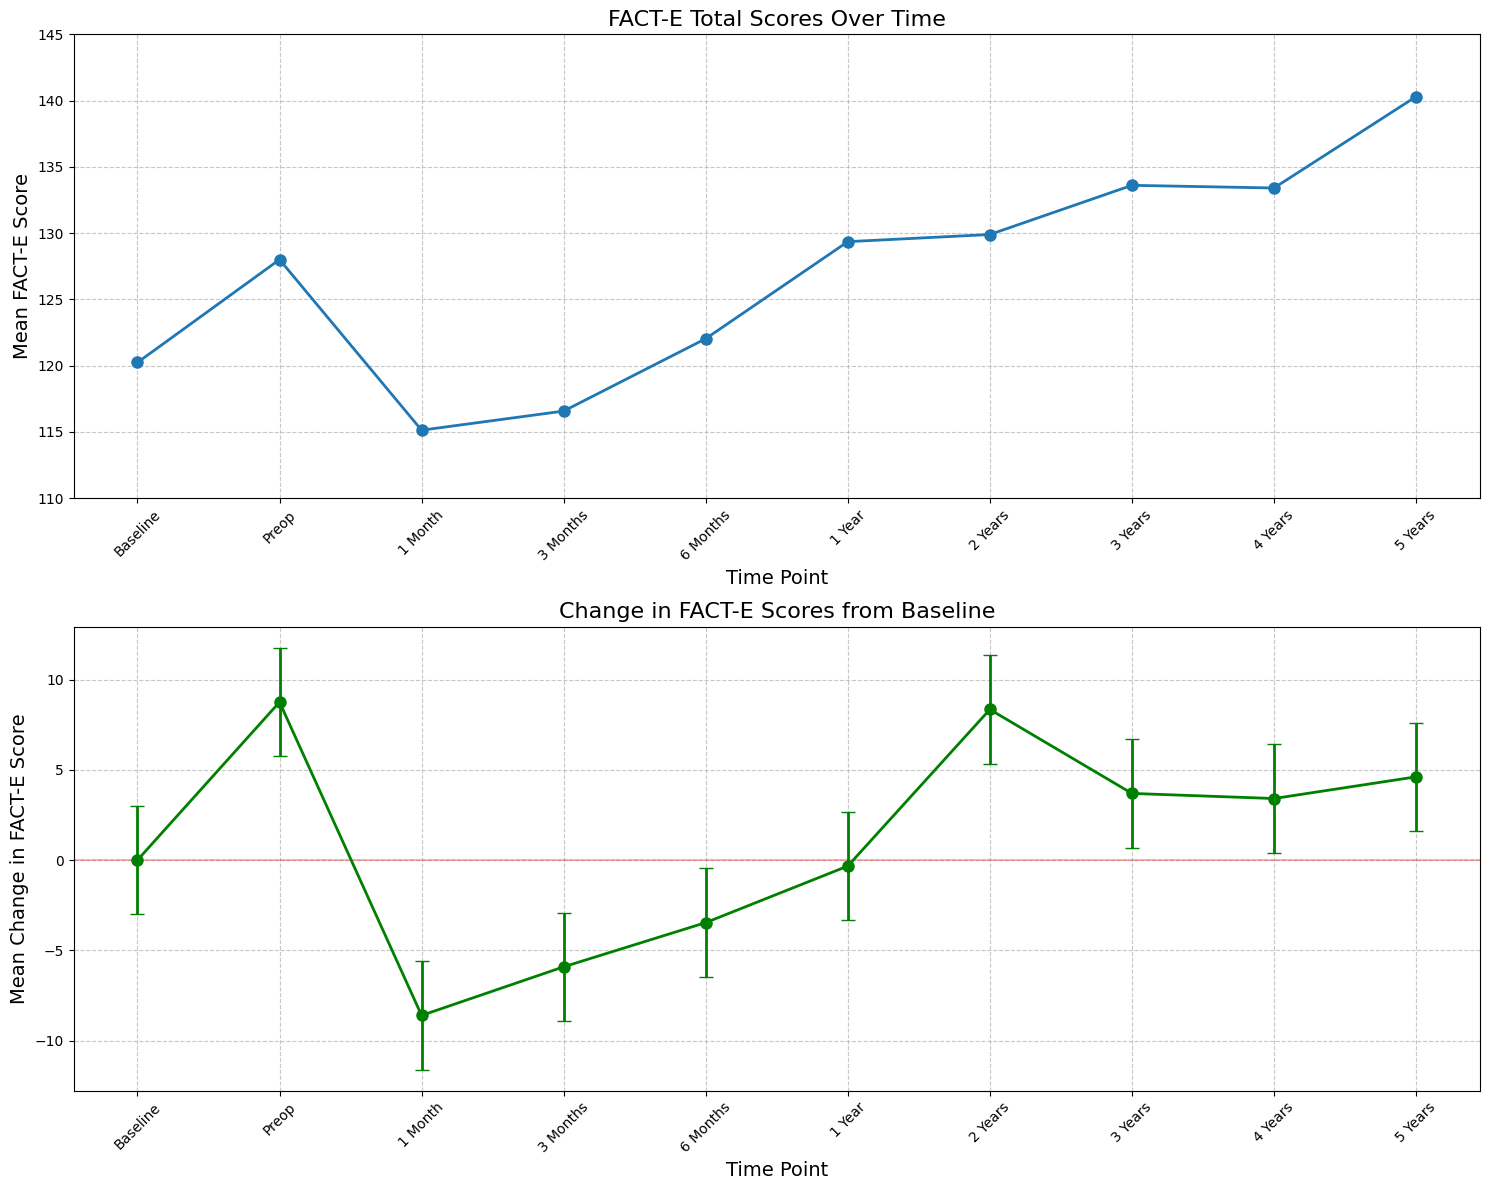

In [36]:

# Set up the figure with two subplots
plt.figure(figsize=(15, 12))

# 1. Plot FACT-E total scores over time (without error bars)
plt.subplot(2, 1, 1)
plt.plot(fact_e_over_time_filtered['time_label'], fact_e_over_time_filtered['mean'], 
        'o-', linewidth=2, markersize=8)
plt.title('FACT-E Total Scores Over Time', fontsize=16)
plt.ylabel('Mean FACT-E Score', fontsize=14)
plt.xlabel('Time Point', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.ylim(110, 145)  # Set y-axis limit from 110 to 145

# 2. Plot change in FACT-E scores over time (with fixed error bars of +/- 3)
plt.subplot(2, 1, 2)
plt.errorbar(change_over_time_with_baseline['time_label'], change_over_time_with_baseline['mean'], 
            yerr=3,  # Fixed error bar of +/- 3
            fmt='o-', capsize=5, linewidth=2, markersize=8, color='green')
plt.title('Change in FACT-E Scores from Baseline', fontsize=16)
plt.ylabel('Mean Change in FACT-E Score', fontsize=14)
plt.xlabel('Time Point', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)  # Add reference line at 0

plt.tight_layout()
plt.show()